In [1]:
import numpy as np
from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel

import os
from enum import Enum

In [2]:
load_dotenv()

True

In [3]:
LLM_API_URL = os.environ["LLM_API_URL"]
LLM_API_TOKEN = os.environ["LLM_API_TOKEN"]

MODEL = "mistralai/ministral-3-3b"

In [4]:
client = OpenAI(
    base_url=LLM_API_URL,
    api_key=LLM_API_TOKEN
)

In [5]:
#models = [m.id for m in client.models.list().data]
#models

In [6]:
# response = client.chat.completions.create(
#     model=MODEL,
#     messages=[{"role": "user", "content": "Hi!"}]
# )

# response.choices[0].message.content

# Modélisation du monde

In [7]:
VOID        = 0
PLAYER      = 1
ENNEMY      = 2
GOLD        = 3

SYMBOLS = {VOID: "·", PLAYER: "👤", ENNEMY: "👹", GOLD: "💰"}

In [8]:

# initial_map = np.array([
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 1, 0, 0, 2, 0, 3], # (1, 1) # (1, 4) # (1, 6)
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 3], # (5, 6)
#     [0, 0, 0, 0, 0, 0, 0],
# ])
# initial_map



# initial_map = np.array([
#     [0, 0, 0, 0, 2, 0, 0],
#     [3, 1, 0, 0, 2, 0, 3], # (1, 1) # (1, 4) # (1, 6)
#     [0, 0, 2, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 3], # (5, 6)
#     [0, 0, 0, 0, 0, 0, 0],
# ])
# initial_map



# Map 21x21 (3x plus grande)
initial_map = np.array([
    [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0],
    [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 2, 0],
    [0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0],
    [0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0],
    [0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
    [3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3], # joueur au centre (10, 10)
    [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0],
    [0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0],
    [0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0],
])
initial_map


array([[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 2, 0],
       [0, 0, 0, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 0],
       [0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
       [3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0,

# Couche de contrat

In [9]:
class Direction(str, Enum):
    HAUT       = "HAUT"
    BAS        = "BAS"
    GAUCHE     = "GAUCHE"
    DROITE     = "DROITE"


# class Confidence(str, Enum):
#     HIGHT       = "HIGHT"
#     MEDIUM      = "MEDIUM"
#     LOW         = "LOW"


class PlayerDecision(BaseModel):
    direction: Direction
    # playerDecision: str
    # confidence: Confidence

MOVES = {
    "HAUT":     (-1, 0),
    "BAS":      ( 1,  0),
    "GAUCHE":   ( 0,  -1),
    "DROITE":   ( 0,   1),
}

# Moteur de perception (directionnel)

In [10]:
def localize(world_map, entity):
    positions = np.argwhere(world_map == entity)
    return positions

In [11]:
localize(initial_map, ENNEMY)

array([[ 0, 10],
       [ 1,  1],
       [ 1, 19],
       [ 2,  8],
       [ 3, 12],
       [ 4,  2],
       [ 5, 15],
       [ 7,  4],
       [ 7, 16],
       [ 9, 13],
       [11,  3],
       [11, 17],
       [13,  2],
       [13, 19],
       [14, 11],
       [16,  6],
       [17,  9],
       [18, 15],
       [19,  1],
       [19, 20],
       [20, 14]])

In [12]:
def compute_distances(entities_positions, reference_pos):
    if (len(entities_positions) == 0):
        return np.array([])
    
    v = entities_positions - reference_pos
    distances = np.linalg.norm(v, axis=1)
 
    return np.round(distances, 2)

In [13]:
golds_distances = compute_distances(localize(initial_map, GOLD), (1, 1))
ennemies_distances = compute_distances(localize(initial_map, ENNEMY), (1, 1))
print(golds_distances, ennemies_distances)

[ 4.12 13.04 16.    2.24 15.13  8.54 18.44  5.   11.18  9.22 18.38  9.06
 21.02 13.04 17.69 13.6  22.02 15.   20.   17.26 19.31 21.02] [ 9.06  0.   18.    7.07 11.18  3.16 14.56  6.71 16.16 14.42 10.2  18.87
 12.04 21.63 16.4  15.81 17.89 22.02 18.   26.17 23.02]


In [14]:
def delta_to_compass(delta_row, delta_col) -> str:
    """Convertit un delta (row, col) en direction cardinale lisible par le LLM."""
    vert = ""
    horiz = ""
    if delta_row < 0:
        vert = "NORD"
    elif delta_row > 0:
        vert = "SUD"
    if delta_col < 0:
        horiz = "OUEST"
    elif delta_col > 0:
        horiz = "EST"

    if vert and horiz:
        return f"{vert}-{horiz}"
    return vert or horiz or "ICI"


def perception(world_map: np.ndarray) -> dict:
    n_rows, n_cols = world_map.shape
    player_position = localize(world_map, PLAYER)[0]
    golds_positions = localize(world_map, GOLD)
    ennemies_positions = localize(world_map, ENNEMY)

    golds_distances = compute_distances(golds_positions, player_position)
    ennemies_distances = compute_distances(ennemies_positions, player_position)

    # Perception directionnelle : or
    golds_info = []
    for i, pos in enumerate(golds_positions):
        delta = pos - player_position
        golds_info.append({
            "distance": float(round(golds_distances[i], 2)),
            "direction": delta_to_compass(int(delta[0]), int(delta[1])),
            "delta_row": int(delta[0]),
            "delta_col": int(delta[1]),
        })
    # Trier par distance croissante
    golds_info.sort(key=lambda x: x["distance"])

    # Perception directionnelle : ennemis
    ennemies_info = []
    for i, pos in enumerate(ennemies_positions):
        delta = pos - player_position
        ennemies_info.append({
            "distance": float(round(ennemies_distances[i], 2)),
            "direction": delta_to_compass(int(delta[0]), int(delta[1])),
        })
    ennemies_info.sort(key=lambda x: x["distance"])

    # Mouvements bloqués (bords ou obstacle)
    r, c = int(player_position[0]), int(player_position[1])
    blocked_directions = []
    for dir_name, (dr, dc) in MOVES.items():
        nr, nc = r + dr, c + dc
        if not (0 <= nr < n_rows and 0 <= nc < n_cols):
            blocked_directions.append(dir_name)
        elif world_map[nr, nc] == ENNEMY:
            blocked_directions.append(dir_name)

    return {
        "player_position": {"row": r, "col": c},
        "golds": golds_info,
        "golds_count": len(golds_info),
        "ennemies": ennemies_info,
        "ennemies_count": len(ennemies_info),
        "blocked_directions": blocked_directions,
    }


p = perception(initial_map)
p

{'player_position': {'row': 10, 'col': 10},
 'golds': [{'distance': 2.83,
   'direction': 'SUD-OUEST',
   'delta_row': 2,
   'delta_col': -2},
  {'distance': 3.61,
   'direction': 'NORD-OUEST',
   'delta_row': -2,
   'delta_col': -3},
  {'distance': 4.12, 'direction': 'NORD-EST', 'delta_row': -4, 'delta_col': 1},
  {'distance': 5.0, 'direction': 'SUD-EST', 'delta_row': 3, 'delta_col': 4},
  {'distance': 6.08,
   'direction': 'NORD-OUEST',
   'delta_row': -6,
   'delta_col': -1},
  {'distance': 6.4, 'direction': 'SUD-OUEST', 'delta_row': 4, 'delta_col': -5},
  {'distance': 7.62, 'direction': 'SUD-EST', 'delta_row': 7, 'delta_col': 3},
  {'distance': 8.25, 'direction': 'NORD-EST', 'delta_row': -2, 'delta_col': 8},
  {'distance': 9.22, 'direction': 'NORD-EST', 'delta_row': -7, 'delta_col': 6},
  {'distance': 9.22,
   'direction': 'SUD-OUEST',
   'delta_row': 9,
   'delta_col': -2},
  {'distance': 9.43, 'direction': 'SUD-EST', 'delta_row': 5, 'delta_col': 8},
  {'distance': 9.85,
   'direc

In [15]:
def show_map(world_map):
    for row in world_map:
        print("\t".join(SYMBOLS.get(cell, "?") for cell in row))
    print('-----------------------------------------------------')

In [16]:
show_map(initial_map)

·	·	·	·	·	💰	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·
·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	👹	·
·	·	·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·
·	·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·
·	💰	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·
·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·
·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·	·	·
💰	·	·	·	·	·	·	·	·	·	👤	·	·	·	·	·	·	·	·	·	💰
·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·
·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	·
·	·	👹	·	·	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	👹	·
·	·	·	·	·	💰	·	·	·	·	·	👹	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·	·
·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·
·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	👹
·	·	·	·	·	·	·	·	·	·	💰	·	·	·	👹	·	·	·	·	·	·
-----------------------------------------------------


# Moteur de déplacement

In [17]:
def allowed_move(world_map: np.ndarray, pos):
    n_rows, n_cols = world_map.shape
    r, c = pos

    if r < 0 or c < 0 or r >= n_rows or c >= n_cols:
        return False
    
    return world_map[r, c] in (VOID, GOLD)

In [18]:
def move(world_map: np.ndarray, old_pos, new_pos):
    if not allowed_move(world_map, new_pos):
        return old_pos
    
    entity = world_map[old_pos[0], old_pos[1]]

    if world_map[old_pos[0], old_pos[1]] == GOLD:
        print(" 💰 Or ramassé !")
        
    world_map[old_pos[0], old_pos[1]] = VOID
    world_map[new_pos[0], new_pos[1]] = entity

    return new_pos

In [19]:
# player_pos = localize(initial_map, PLAYER)[0]
# move(initial_map, player_pos, player_pos + 1)

# Moteur de décision

In [20]:
def decide(player_perception, move_history: list, model: str = MODEL) -> PlayerDecision | None:
    history_str = "\n".join(f"  - {m}" for m in move_history) if move_history else "  (aucun)"

    golds_str = "\n".join(
        f"  - Or #{i+1} : direction {g['direction']}, distance {g['distance']}"
        for i, g in enumerate(player_perception.get("golds", []))
    ) or "  (aucun or restant)"

    ennemies_str = "\n".join(
        f"  - Ennemi #{i+1} : direction {e['direction']}, distance {e['distance']}"
        for i, e in enumerate(player_perception.get("ennemies", []))
    ) or "  (aucun ennemi)"

    blocked_str = ", ".join(player_perception.get("blocked_directions", [])) or "aucune"

    prompt = f"""
# Contexte
Tu es un joueur dans un jeu de grille. Tu veux ramasser tout l'or le plus vite possible.

# Règles
- Tu peux te déplacer dans 4 directions : HAUT, BAS, GAUCHE, DROITE
- Tu ne peux PAS aller dans une direction bloquée (mur ou ennemi)
- Choisir une direction bloquée compte quand même comme un tour raté

# Ta position
- Ligne {player_perception['player_position']['row']}, Colonne {player_perception['player_position']['col']}

# Or détecté ({player_perception['golds_count']} pièce(s))
{golds_str}

# Ennemis ({player_perception['ennemies_count']})
{ennemies_str}

# Directions bloquées
{blocked_str}

# Historique de tes derniers mouvements
{history_str}

# Objectif
Choisis la direction qui te rapproche le plus vite de l'or le plus proche, en évitant les directions bloquées.
"""

    response = client.beta.chat.completions.parse(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_format=PlayerDecision,
        temperature=0.3,
    )

    return response.choices[0].message.parsed or None

In [21]:
# p = perception(initial_map)
# decision: PlayerDecision = decide(p)
# decision.direction.value

# Game loop (simulation) + collecte bronze

In [22]:
def game_loop(world_map: np.ndarray, max_turns=10, simulation_id: str = "sim_1", model: str = MODEL) -> list[dict]:
    """
    Retourne les données brutes (couche Bronze) : une ligne par tour.
    """
    world_map = world_map.copy()
    bronze_records = []
    move_history = []

    initial_gold_count = int(np.sum(world_map == GOLD))

    for turn in range(max_turns):
        print(f"\n =================== [Turn {turn + 1}] ===================")
        show_map(world_map)

        gold_remaining = int(np.sum(world_map == GOLD))
        if gold_remaining == 0:
            print("🏆 Tout l'or a été ramassé !")
            break

        player_pos = tuple(localize(world_map, PLAYER)[0])
        p = perception(world_map)

        decision = decide(p, move_history[-5:], model=model)

        direction = None
        moved = False
        was_blocked = False
        gold_collected = False

        if decision is not None:
            direction = decision.direction.value
            print(f"\t → LLM decision: {direction}")

            d_row, d_col = MOVES[direction]
            new_pos = (player_pos[0] + d_row, player_pos[1] + d_col)

            gold_before = int(np.sum(world_map == GOLD))
            result_pos = move(world_map, player_pos, new_pos)
            gold_after = int(np.sum(world_map == GOLD))

            moved = result_pos != player_pos
            was_blocked = not moved
            gold_collected = gold_after < gold_before

            move_history.append(f"{direction} ({'ok' if moved else 'BLOQUÉ'})")

        # Enregistrement Bronze
        bronze_records.append({
            "simulation_id": simulation_id,
            "model": model,
            "turn": turn + 1,
            "player_row": player_pos[0],
            "player_col": player_pos[1],
            "golds_count": p["golds_count"],
            "ennemies_count": p["ennemies_count"],
            "nearest_gold_direction": p["golds"][0]["direction"] if p["golds"] else None,
            "nearest_gold_distance": p["golds"][0]["distance"] if p["golds"] else None,
            "blocked_directions": p["blocked_directions"],
            "decision": direction,
            "moved": moved,
            "was_blocked": was_blocked,
            "gold_collected": gold_collected,
            "gold_remaining": int(np.sum(world_map == GOLD)),
            "initial_gold_count": initial_gold_count,
        })

    return bronze_records

In [23]:
bronze_data = game_loop(world_map=initial_map, max_turns=30, simulation_id="sim_1")
print(f"\n📦 {len(bronze_data)} enregistrements bronze collectés.")


 =================== [Turn 1] ===================
·	·	·	·	·	💰	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·
·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	👹	·
·	·	·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·
·	·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·
·	💰	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·
·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·
·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·	·	·
💰	·	·	·	·	·	·	·	·	·	👤	·	·	·	·	·	·	·	·	·	💰
·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·
·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	·
·	·	👹	·	·	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	👹	·
·	·	·	·	·	💰	·	·	·	·	·	👹	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·	·
·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·
·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	👹
·	·	·	·	·	·	·	·	·	·	💰	·	·	·	👹	·	·	·	·	·	·
-----------------------------------------------------
	 → LLM decis

# Pipeline de Data Ingénierie — Architecture Médaillon

```
Bronze  →  résultats bruts de la simulation (1 ligne = 1 tour)
Silver  →  données propres + enrichissement
Gold    →  agrégats métier par simulation
```

## 🥉 Couche Bronze — Résultats bruts

In [40]:
import pandas as pd

df_bronze = pd.DataFrame(bronze_data)
print(f"Shape: {df_bronze.shape}")
df_bronze.head()

Shape: (30, 16)


,simulation_id,model,turn,player_row,player_col,golds_count,ennemies_count,nearest_gold_direction,nearest_gold_distance,blocked_directions,decision,moved,was_blocked,gold_collected,gold_remaining,initial_gold_count
0,sim_1,mistralai/ministral-3-3b,1,10,10,22,21,SUD-OUEST,2.83,[],BAS,True,False,False,22,22
1,sim_1,mistralai/ministral-3-3b,2,11,10,22,21,SUD-OUEST,2.24,[],DROITE,True,False,False,22,22
2,sim_1,mistralai/ministral-3-3b,3,11,11,22,21,SUD-OUEST,3.16,[],DROITE,True,False,False,22,22
3,sim_1,mistralai/ministral-3-3b,4,11,12,22,21,SUD-EST,2.83,[],HAUT,True,False,False,22,22
4,sim_1,mistralai/ministral-3-3b,5,10,12,22,21,SUD-EST,3.61,[],HAUT,True,False,False,22,22


In [41]:
import os, subprocess, duckdb

# ── 1. Sauvegarder Bronze en Parquet ──────────────────────────────
os.makedirs("data", exist_ok=True)
df_bronze.to_parquet("data/bronze.parquet", index=False)
print(f"✅ Bronze → data/bronze.parquet  ({len(df_bronze)} lignes)")

# ── 2. Lancer dbt (Silver + Gold via DuckDB) ──────────────────────
result = subprocess.run(
    ["dbt", "run", "--project-dir", "dbt_npc", "--profiles-dir", "dbt_npc"],
    capture_output=True, text=True
)
print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
if result.returncode != 0:
    print("STDERR :", result.stderr[-500:])

# ── 3. Lire Silver et Gold depuis DuckDB ──────────────────────────
con = duckdb.connect("data/npc_brain.duckdb", read_only=True)
df_silver = con.execute("SELECT * FROM silver WHERE simulation_id = 'sim_1'").df()
df_gold   = con.execute("SELECT * FROM gold   WHERE simulation_id = 'sim_1'").df()
con.close()
print(f"✅ Silver : {df_silver.shape} | Gold : {df_gold.shape}")
df_silver[["simulation_id", "turn", "decision", "nearest_gold_direction",
           "decision_correct", "moved", "gold_collected", "gold_collected_cumsum"]].head(10)


✅ Bronze → data/bronze.parquet  (30 lignes)

STDERR : 
✅ Silver : (30, 22) | Gold : (1, 12)


,simulation_id,turn,decision,nearest_gold_direction,decision_correct,moved,gold_collected,gold_collected_cumsum
0,sim_1,1,DROITE,SUD-OUEST,False,True,False,0.0
1,sim_1,2,HAUT,SUD-OUEST,False,True,False,0.0
2,sim_1,3,HAUT,NORD,True,True,False,0.0
3,sim_1,4,HAUT,NORD,True,True,False,0.0
4,sim_1,5,HAUT,NORD,True,True,True,1.0
5,sim_1,6,DROITE,NORD-OUEST,False,True,False,1.0
6,sim_1,7,DROITE,NORD-OUEST,False,True,False,1.0
7,sim_1,8,DROITE,NORD-EST,True,True,False,1.0
8,sim_1,9,HAUT,NORD-EST,True,True,False,1.0
9,sim_1,10,HAUT,NORD-EST,True,True,False,1.0


## 🥈 Couche Silver — Données propres et enrichies

In [42]:

# ── Logique Silver en Python (documentation — remplacée par dbt_npc/models/silver.sql) ──
def build_silver(df_bronze: pd.DataFrame) -> pd.DataFrame:
    df = df_bronze.copy()

    # Nettoyage : remplacer les valeurs nulles
    df["nearest_gold_direction"] = df["nearest_gold_direction"].fillna("AUCUN")
    df["nearest_gold_distance"] = df["nearest_gold_distance"].fillna(0.0)

    # Enrichissement : la décision allait-elle dans la bonne direction ?
    DIRECTION_COMPASS_MAP = {
        "HAUT":   ["NORD", "NORD-EST", "NORD-OUEST"],
        "BAS":    ["SUD",  "SUD-EST",  "SUD-OUEST"],
        "GAUCHE": ["OUEST", "NORD-OUEST", "SUD-OUEST"],
        "DROITE": ["EST",   "NORD-EST",   "SUD-EST"],
    }

    def is_correct_direction(row):
        if row["golds_count"] == 0 or row["decision"] is None:
            return False
        good_dirs = DIRECTION_COMPASS_MAP.get(row["decision"], [])
        return row["nearest_gold_direction"] in good_dirs

    df["decision_correct"] = df.apply(is_correct_direction, axis=1)

    # Enrichissement : or collecté cumulé par simulation
    df["gold_collected_cumsum"] = df.groupby("simulation_id")["gold_collected"].cumsum().astype(int)

    # Enrichissement : numéro de bloc de n tours (utile pour rolling stats)
    df["turn_block"] = ((df["turn"] - 1) // 5) * 5 + 1

    # Calcul du déplacement Manhattan entre tours consécutifs
    df["prev_row"] = df.groupby("simulation_id")["player_row"].shift(1)
    df["prev_col"] = df.groupby("simulation_id")["player_col"].shift(1)
    df["manhattan_move"] = (
        (df["player_row"] - df["prev_row"]).abs() +
        (df["player_col"] - df["prev_col"]).abs()
    ).fillna(0).astype(int)

    df = df.drop(columns=["prev_row", "prev_col"])

    return df

# df_silver provient du pipeline dbt + DuckDB (cellule précédente)
print(f"Shape silver : {df_silver.shape}")


Shape silver : (30, 22)


## 🥇 Couche Gold — Agrégats métier par simulation

In [43]:

# ── Logique Gold en Python (documentation — remplacée par dbt_npc/models/gold.sql) ──
def build_gold(df_silver: pd.DataFrame) -> pd.DataFrame:
    agg = df_silver.groupby("simulation_id").agg(
        total_turns             = ("turn", "max"),
        gold_collected          = ("gold_collected", "sum"),
        initial_gold            = ("initial_gold_count", "first"),
        blocked_turns           = ("was_blocked", "sum"),
        correct_decisions       = ("decision_correct", "sum"),
        total_decisions         = ("decision", "count"),
        avg_nearest_gold_dist   = ("nearest_gold_distance", "mean"),
    ).reset_index()

    agg["gold_collection_rate"]     = agg["gold_collected"] / agg["initial_gold"].replace(0, 1)
    agg["decision_accuracy"]        = agg["correct_decisions"] / agg["total_decisions"].replace(0, 1)
    agg["efficiency_score"]         = (
        agg["gold_collection_rate"] * 0.6 +
        agg["decision_accuracy"]   * 0.3 +
        (1 - agg["blocked_turns"] / agg["total_turns"].replace(0, 1)) * 0.1
    ).round(3)

    def classify(row):
        if row["gold_collection_rate"] == 1.0:
            return "Victoire complète"
        elif row["gold_collection_rate"] >= 0.5:
            return "Victoire partielle"
        elif row["gold_collected"] > 0:
            return "Progrès minimal"
        else:
            return "Échec"

    agg["simulation_type"] = agg.apply(classify, axis=1)
    return agg

# df_gold provient du pipeline dbt + DuckDB (cellule précédente)
df_gold


,simulation_id,total_turns,gold_collected,initial_gold,blocked_turns,correct_decisions,total_decisions,avg_nearest_gold_dist,gold_collection_rate,decision_accuracy,efficiency_score,simulation_type
0,sim_1,30,4.0,22,0.0,22.0,30,2.802333,0.181818,0.733333,0.429,Progrès minimal


## 📊 Reporting — Datavisualisation par simulation

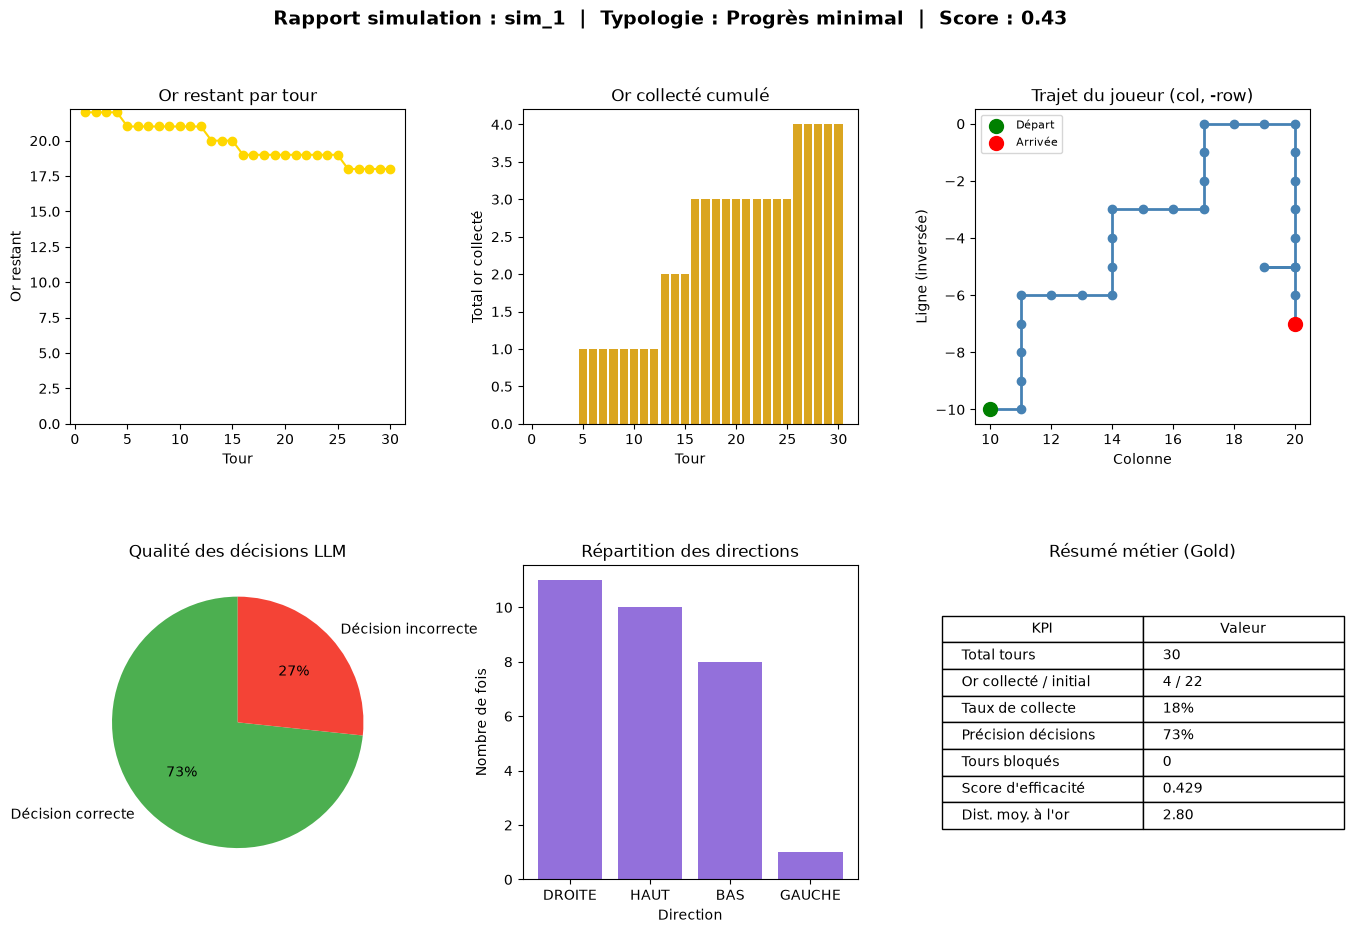

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_simulation_report(df_silver: pd.DataFrame, df_gold: pd.DataFrame, simulation_id: str):
    df_sim = df_silver[df_silver["simulation_id"] == simulation_id].copy()
    gold_row = df_gold[df_gold["simulation_id"] == simulation_id].iloc[0]

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f"Rapport simulation : {simulation_id}  |  Typologie : {gold_row['simulation_type']}  |  Score : {gold_row['efficiency_score']:.2f}",
        fontsize=14, fontweight="bold"
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── 1. Or restant au fil des tours ──────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df_sim["turn"], df_sim["gold_remaining"], marker="o", color="gold")
    ax1.set_title("Or restant par tour")
    ax1.set_xlabel("Tour")
    ax1.set_ylabel("Or restant")
    ax1.set_ylim(bottom=0)

    # ── 2. Or collecté cumulé ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(df_sim["turn"], df_sim["gold_collected_cumsum"], color="goldenrod")
    ax2.set_title("Or collecté cumulé")
    ax2.set_xlabel("Tour")
    ax2.set_ylabel("Total or collecté")

    # ── 3. Trajet du joueur ─────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(df_sim["player_col"], -df_sim["player_row"], marker="o", color="steelblue", linewidth=2)
    ax3.scatter(df_sim["player_col"].iloc[0],  -df_sim["player_row"].iloc[0],  color="green", s=100, zorder=5, label="Départ")
    ax3.scatter(df_sim["player_col"].iloc[-1], -df_sim["player_row"].iloc[-1], color="red",   s=100, zorder=5, label="Arrivée")
    ax3.set_title("Trajet du joueur (col, -row)")
    ax3.set_xlabel("Colonne")
    ax3.set_ylabel("Ligne (inversée)")
    ax3.legend(fontsize=8)

    # ── 4. Décisions : bonnes vs mauvaises ─────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0])
    correct = int(df_sim["decision_correct"].sum())
    incorrect = len(df_sim) - correct
    ax4.pie(
        [correct, incorrect],
        labels=["Décision correcte", "Décision incorrecte"],
        colors=["#4CAF50", "#F44336"],
        autopct="%1.0f%%",
        startangle=90,
    )
    ax4.set_title("Qualité des décisions LLM")

    # ── 5. Directions choisies ──────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    direction_counts = df_sim["decision"].value_counts()
    ax5.bar(direction_counts.index, direction_counts.values, color="mediumpurple")
    ax5.set_title("Répartition des directions")
    ax5.set_xlabel("Direction")
    ax5.set_ylabel("Nombre de fois")

    # ── 6. KPIs Gold ────────────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    kpis = [
        ("Total tours",              f"{int(gold_row['total_turns'])}"),
        ("Or collecté / initial",    f"{int(gold_row['gold_collected'])} / {int(gold_row['initial_gold'])}"),
        ("Taux de collecte",         f"{gold_row['gold_collection_rate']:.0%}"),
        ("Précision décisions",      f"{gold_row['decision_accuracy']:.0%}"),
        ("Tours bloqués",            f"{int(gold_row['blocked_turns'])}"),
        ("Score d'efficacité",       f"{gold_row['efficiency_score']:.3f}"),
        ("Dist. moy. à l'or",        f"{gold_row['avg_nearest_gold_dist']:.2f}"),
    ]
    table_data = [[k, v] for k, v in kpis]
    table = ax6.table(cellText=table_data, colLabels=["KPI", "Valeur"],
                      loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.6)
    ax6.set_title("Résumé métier (Gold)")

    plt.show()


plot_simulation_report(df_silver, df_gold, simulation_id="sim_1")

# Benchmark — Comparaison des modèles

In [32]:
BENCHMARK_MODELS = [
    "mistralai/ministral-3-3b",
    "google/gemma-4-e2b",
]

all_bronze = []
for m in BENCHMARK_MODELS:
    print(f"\n{'='*60}\n🤖 Modèle : {m}\n{'='*60}")
    records = game_loop(world_map=initial_map, max_turns=30, simulation_id=m, model=m)
    all_bronze.extend(records)

df_bench_bronze = pd.DataFrame(all_bronze)

# ── Sauvegarder bronze combiné (sim_1 + benchmark) et relancer dbt ──
df_all_bronze = pd.concat([df_bronze, df_bench_bronze], ignore_index=True)
df_all_bronze.to_parquet("data/bronze.parquet", index=False)
print(f"\n✅ Bronze combiné → data/bronze.parquet  ({len(df_all_bronze)} lignes)")

result = subprocess.run(
    ["dbt", "run", "--project-dir", "dbt_npc", "--profiles-dir", "dbt_npc"],
    capture_output=True, text=True
)
print(result.stdout[-1500:] if len(result.stdout) > 1500 else result.stdout)
if result.returncode != 0:
    print("STDERR :", result.stderr[-500:])

# ── Lire les résultats benchmark depuis DuckDB ──
bench_ids = "', '".join(BENCHMARK_MODELS)
con = duckdb.connect("data/npc_brain.duckdb", read_only=True)
df_bench_silver = con.execute(f"SELECT * FROM silver WHERE simulation_id IN ('{bench_ids}')").df()
df_bench_gold   = con.execute(f"SELECT * FROM gold   WHERE simulation_id IN ('{bench_ids}')").df()
con.close()

df_bench_gold[["simulation_id", "total_turns", "gold_collected", "gold_collection_rate",
               "decision_accuracy", "blocked_turns", "efficiency_score", "simulation_type"]]



🤖 Modèle : mistralai/ministral-3-3b

 =================== [Turn 1] ===================
·	·	·	·	·	💰	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·
·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	👹	·
·	·	·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·
·	·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·
·	💰	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·
·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·
·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·	·	·
💰	·	·	·	·	·	·	·	·	·	👤	·	·	·	·	·	·	·	·	·	💰
·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	👹	·	·	·
·	·	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	·
·	·	👹	·	·	·	·	·	·	·	·	·	·	·	💰	·	·	·	·	👹	·
·	·	·	·	·	💰	·	·	·	·	·	👹	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	·	💰	·	·
·	💰	·	·	·	·	👹	·	·	·	·	·	·	·	·	·	·	·	·	·	·
·	·	·	·	·	·	·	·	·	👹	·	·	·	💰	·	·	·	·	·	·	·
·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	👹	·	·	·	·	·
·	👹	·	·	·	·	·	·	💰	·	·	·	·	·	·	·	·	·	·	·	👹
·	·	·	·	·	·	·	·	·	·	💰	·	·	·	👹	·	·	·	·	·	·
------------------------------

,simulation_id,total_turns,gold_collected,gold_collection_rate,decision_accuracy,blocked_turns,efficiency_score,simulation_type


IndexError: single positional indexer is out-of-bounds

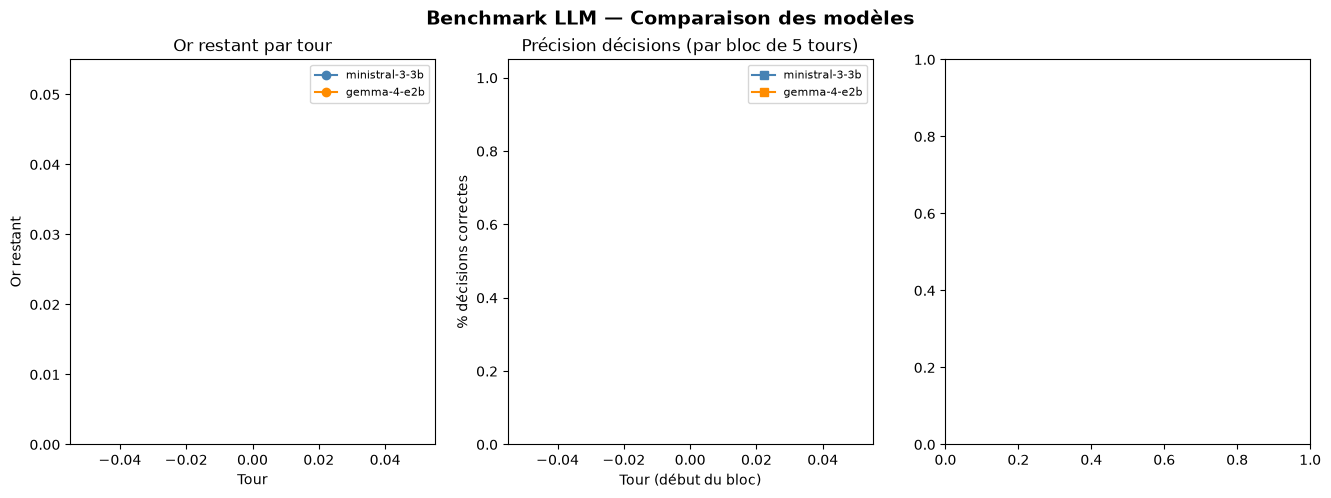

In [39]:
colors = ["steelblue", "darkorange"]
model_labels = [m.split("/")[-1] for m in BENCHMARK_MODELS]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Benchmark LLM — Comparaison des modèles", fontsize=14, fontweight="bold")

# ── 1. Or restant au fil des tours ──────────────────────────────────────────
ax = axes[0]
for m, color, label in zip(BENCHMARK_MODELS, colors, model_labels):
    d = df_bench_silver[df_bench_silver["simulation_id"] == m]
    ax.plot(d["turn"], d["gold_remaining"], marker="o", color=color, label=label)
ax.set_title("Or restant par tour")
ax.set_xlabel("Tour")
ax.set_ylabel("Or restant")
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── 2. Précision des décisions par bloc de 5 tours ──────────────────────────
ax = axes[1]
for m, color, label in zip(BENCHMARK_MODELS, colors, model_labels):
    d = df_bench_silver[df_bench_silver["simulation_id"] == m]
    acc_by_block = d.groupby("turn_block")["decision_correct"].mean()
    ax.plot(acc_by_block.index, acc_by_block.values, marker="s", color=color, label=label)
ax.set_title("Précision décisions (par bloc de 5 tours)")
ax.set_xlabel("Tour (début du bloc)")
ax.set_ylabel("% décisions correctes")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

# ── 3. KPIs Gold côte à côte ─────────────────────────────────────────────────
ax = axes[2]
kpi_cols = ["gold_collection_rate", "decision_accuracy", "efficiency_score"]
kpi_labels = ["Taux collecte", "Précision LLM", "Score efficacité"]
x = np.arange(len(kpi_labels))
width = 0.35
for i, (m, color, label) in enumerate(zip(BENCHMARK_MODELS, colors, model_labels)):
    row = df_bench_gold[df_bench_gold["simulation_id"] == m].iloc[0]
    ax.bar(x + i * width, [row[k] for k in kpi_cols], width, label=label, color=color)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(kpi_labels, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("KPIs Gold comparés")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()